In [1]:
import debugpy
debugpy.configure(subProcess=False)

In [2]:
import os
import sys
from pathlib import Path
# Add parent directory to path (most common use case)
cwd = Path(os.getcwd())
if cwd.name == 'notebooks':
    sys.path.append(os.path.abspath('..'))

In [3]:
if cwd.name == 'notebooks':
    os.chdir('..')

In [ ]:
from dotenv import load_dotenv
from pathlib import Path

import uuid
import random
import numpy as np

# Visualisation
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

from scipy import stats
from sklearn.cluster import DBSCAN

from iconfig.iconfig import iConfig
# Local imports
from ct.data_preparation import load_data, initial_cleaning

In [5]:
# autoreload
%load_ext autoreload
%autoreload 2

In [6]:
# Load environment variables
load_dotenv() 
# Remove warnings
warnings.filterwarnings("ignore") 

In [7]:
# Read the configuration files
config = iConfig()

# Load data

In [8]:
srcdir = Path("/mnt/c/Users/heine/Downloads/2000k_Chicken")
# srcdir = Path("/mnt/c/Users/heine/Downloads/1500k_corrected_chicken")

In [9]:
species = 'chicken'

In [10]:
# Load all files and do initial cleaning
df = load_data(srcdir)
df = initial_cleaning(df=df, config=config)


In [11]:
df.head()

,AnomalyId,LocalTime,FarmId,FarmName,ShedId,ShedName,Correlation,Category
0,a0e98d0e-4f80-41af-b179-49d5a22b3e33,2025-11-24 04:50:00,786c9f2f-0d9d-4062-a33d-c9db28ed773c,CAR-RO-BR-Francesti 1,70eacc3e-a62d-455f-875c-c8d302865132,House 09,Water consumption total [L],Decreased Water
1,d43f1ec5-523a-45b0-83ff-cb1c89a93cc4,2025-11-24 04:50:00,786c9f2f-0d9d-4062-a33d-c9db28ed773c,CAR-RO-BR-Francesti 1,ac0373c0-2dda-4175-8755-5f8a12e7bbf1,House 11,Ventilation Decreased,Decreased Water
2,c9699a4e-767d-42ca-870e-277761c20f2f,2025-11-24 04:50:00,2077bc8a-7720-40f8-baf1-d1559b5b6011,ECP-SA-BR-Abumaan,c92e5d7c-f72a-4860-9858-b59c4c82d6d3,House 04,Water consumption total [L],Decreased Water
3,c9699a4e-767d-42ca-870e-277761c20f2f,2025-11-24 04:50:00,2077bc8a-7720-40f8-baf1-d1559b5b6011,ECP-SA-BR-Abumaan,c92e5d7c-f72a-4860-9858-b59c4c82d6d3,House 04,Outside Temperature Decreased,Decreased Water
4,d43f1ec5-523a-45b0-83ff-cb1c89a93cc4,2025-11-24 04:50:00,786c9f2f-0d9d-4062-a33d-c9db28ed773c,CAR-RO-BR-Francesti 1,ac0373c0-2dda-4175-8755-5f8a12e7bbf1,House 11,Water consumption total [L],Decreased Water


In [12]:
if species == 'chicken':
    allowable_farm_categories = ['BR']
elif species == 'pig':
    raise NotImplementedError("Pig correlations not implemented yet")

In [13]:
def is_allowed_farm(farmname:str, allowable_farm_categories:list) -> bool:
    # If the name complies with the nomenclature XXX-YY-ZZ where ZZ is in allowable_farm_categories, 
    # filter depending on farm category, else allow it
    parts = farmname.split('-')
    if len(parts) >= 3:
        return parts[2] in allowable_farm_categories
    return True

farms = df['FarmName'].unique()
allowed_farms = [farm for farm in farms if is_allowed_farm(farm, allowable_farm_categories)]
allowed_farms

['CAR-RO-BR-Francesti 1',
 'ECP-SA-BR-Abumaan',
 'AAM-AU-BR-Karinyah',
 'GRE-GB-BR-Warner Farm',
 'ARA-SA-BR-Alkhorayef 1',
 'HUG-GB-BR-Salford Lodge',
 'TER-DE-BR-Gimbsheim',
 'HUG-GB-BR-Rock Farm',
 'ARA-SA-BR-Alkhorayef 3',
 'MOY-GB-BR-Campney Grange Farm',
 'AZI-IT-BR-Santa Maria',
 'BAT-NL-BR-BATO-Pluimvee B.V.',
 'CAR-RO-BR-Baiculesti 6',
 'CAR-RO-BR-Crevedia',
 'NYE-GB-BR-Nyebridge',
 'CAR-RO-BR-Mihailesti',
 'CHU-ZA-BR-Vaalkoppie',
 'ARA-SA-BR-Al Majid 1',
 'AAM-AU-BR-MBP3',
 'ARA-SA-BR-Al Majid 2',
 'CAL-GB-BR-Boiling Wells - Calyx',
 'DID-DK-BR-Dideriksen',
 'BOI-GB-BR-Boiling Wells',
 'FIE-US-BR-Foster Farms INC  1',
 'FIE-US-BR-B Poultry Farm',
 'FIE-US-BR-Blue Creek Farm  2',
 'HAP-NL-BR-Vlagtwedde Farm',
 'ARA-SA-BR-Al Rashed',
 'JJD-GB-BR-Cleathill',
 'MAR-GB-BR-Marris Foston',
 'TER-DE-BR-Walchum',
 'HEM-DE-BR-Achter',
 'WIN-BE-BR-Rob Wingens Farm',
 'FIE-US-BR-Sweet P Farms',
 'AAM-AU-BR-Riverlands 3',
 'FIE-US-BR-Tokeena AG Solutions LLC',
 'FIE-US-BR-Nickles Poutltry

In [14]:
df = df[df['FarmName'].isin(allowed_farms)]


In [15]:
print("*"*80)
print(f"""
    Data loaded from {srcdir}
    Number of records: {len(df):,}
    Number of anomalies: {df['AnomalyId'].nunique():,}
    Number of farms: {df['FarmId'].nunique():,}
    Number of sheds: {df['ShedId'].nunique():,}
""")
print("*"*80)

********************************************************************************

    Data loaded from /mnt/c/Users/heine/Downloads/2000k_Chicken
    Number of records: 1,672,402
    Number of anomalies: 620,871
    Number of farms: 182
    Number of sheds: 769

********************************************************************************


In [16]:
correlations = df[['Correlation','Category']].value_counts().reset_index()
correlations

,Correlation,Category,count
0,Water consumption total [L],Decreased Water,214218
1,Zonal Temperature Variance,Decreased Water,115824
2,Water consumption total [L],Increased Water,82856
3,Air Pressure Decreased,Decreased Water,69306
4,Ventilation Decreased,Decreased Water,64530
...,...,...,...
81,Outside Wind Speed Increased,Decreased Water,78
82,Outside Wind Speed Increased,Increased Water,76
83,Wind Degree East to West,Increased Water,76
84,Outside Wind Speed Decreased,Decreased Water,72


In [17]:
n_correlations = 10

In [18]:
# These are sample correlation for later plotting
if species == 'chicken':
    relevant_correlations = correlations.head(n_correlations)[['Correlation','Category']]
elif species == 'pig':
    raise NotImplementedError("Pig correlations not implemented yet")
relevant_correlations

,Correlation,Category
0,Water consumption total [L],Decreased Water
1,Zonal Temperature Variance,Decreased Water
2,Water consumption total [L],Increased Water
3,Air Pressure Decreased,Decreased Water
4,Ventilation Decreased,Decreased Water
5,Zonal Temperature Variance,Increased Water
6,Air Pressure Increased,Decreased Water
7,Humidity Decreased,Decreased Water
8,Ventilation Increased,Decreased Water
9,Humidity Increased,Decreased Water


# Filter out undesired production systems

In [19]:
def get_sheds_with_highest_number_of_correlation(df: pd.DataFrame, correlations: pd.DataFrame, n_samples: int) -> pd.DataFrame:
    """Extract unique farm and shed combinations from the dataframe."""

    counts = df.groupby(by=['Category','Correlation', 'FarmId', 'FarmName', 'ShedId', 'ShedName']).size().reset_index(name='count')

    ret = pd.DataFrame()

    for _, corr_cat in correlations.iterrows():
        category = corr_cat['Category']
        correlation = corr_cat['Correlation']
        subset = counts[(counts['Category'] == category) & (counts['Correlation'] == correlation)]
        top_sheds = subset.nlargest(n_samples, columns='count') # type: ignore
        ret = pd.concat([ret, top_sheds], ignore_index=True)
    
    return ret

In [20]:
# Select n_samples farms
n_farms = 10
# Some parameters
top_sheds = get_sheds_with_highest_number_of_correlation(df, correlations=relevant_correlations, n_samples=n_farms)
top_sheds

,Category,Correlation,FarmId,FarmName,ShedId,ShedName,count
0,Decreased Water,Water consumption total [L],d2be1634-df55-4b10-8901-c814e5651ba2,CAR-RO-BR-Crevedia,8df05bab-ca1c-4ec8-aa20-15ed90bb4482,House 02,1443
1,Decreased Water,Water consumption total [L],d2be1634-df55-4b10-8901-c814e5651ba2,CAR-RO-BR-Crevedia,f6c2bafa-d1ec-4749-9c84-2ae7c0d44412,House 01,1411
2,Decreased Water,Water consumption total [L],d2be1634-df55-4b10-8901-c814e5651ba2,CAR-RO-BR-Crevedia,25262b77-7bed-46a1-9663-25f6cc39a191,House 04,1295
3,Decreased Water,Water consumption total [L],f18e8523-5360-4733-877b-7cc6df721fee,CAR-RO-BR-Francesti 2,4ad87bed-f741-4de0-9a54-fe83ec4132b9,House 04,1263
4,Decreased Water,Water consumption total [L],f18e8523-5360-4733-877b-7cc6df721fee,CAR-RO-BR-Francesti 2,538c35e9-7d42-4219-ae1a-517b3221bd0c,House 05,1261
...,...,...,...,...,...,...,...
95,Decreased Water,Humidity Increased,b753351b-22fc-4051-8475-98b488585a0e,AAM-AU-BR-Karinyah,0c37cc8b-553c-4e67-af86-2e637f521ba8,House 07,424
96,Decreased Water,Humidity Increased,a03c9a15-4b64-48f9-b547-baf64140ab8b,ANI-GR-BR-Alevo 587-588,f757c9a6-33b4-43f6-941e-e8fd98cd98ed,587A,415
97,Decreased Water,Humidity Increased,a03c9a15-4b64-48f9-b547-baf64140ab8b,ANI-GR-BR-Alevo 587-588,5c21c394-d3a0-4704-8a40-e28a7d0eba55,587B,398
98,Decreased Water,Humidity Increased,4c91a743-4a64-4577-b002-d9131737fee2,PER-SI-BR-Miha Persuh Farm,b6eb27e2-25a4-4d84-b6d4-20fa1d001c32,House 05,395


In [21]:
# Ensure datetime and sort
df = df.sort_values(["FarmName", "ShedName", "LocalTime"]).reset_index(drop=True)

# Convert time to numeric (seconds since epoch)
df["t_seconds"] = df["LocalTime"].astype("int64") // 10**9

# Clustering

In [22]:
# Parameters for DBSCAN
if species == 'chicken':
    EPS_SECONDS = 2*3600    # 2h
elif species == 'pig':
    EPS_SECONDS = 3*3600    # 3h
MIN_SAMPLES = 2         # minimum events per group

In [23]:
# Whether to save the result and into which filename
SAVE_RESULT = True
save_fn = "clustered_data.csv"

In [24]:
CLEAN = True

In [25]:
if CLEAN:
    if Path(srcdir/save_fn).exists():
        os.remove(srcdir/save_fn)

In [26]:
if SAVE_RESULT and (srcdir / save_fn).exists():
    df = pd.read_csv(srcdir / save_fn, parse_dates=['LocalTime'])
    

In [27]:
if "group_id" not in df.columns:
    df["group_id"] = -2

    current_max_id = 0

    group_cols = ["FarmName", "ShedName", "Correlation", "Category"]

    for _, subset in df.groupby(group_cols, sort=False):
        if len(subset) < MIN_SAMPLES:
            continue

        X = subset[["t_seconds"]].to_numpy()

        y = DBSCAN(
            eps=EPS_SECONDS,
            min_samples=MIN_SAMPLES,
            metric="euclidean"
        ).fit_predict(X)

        # Adjust group ids to be unique across all subsets while keeping -1 (invalid cluster) as is
        if (y >= 0).any():
            y[y >= 0] += current_max_id + 1
            current_max_id = y.max()

        df.loc[subset.index, "group_id"] = y

In [28]:
if SAVE_RESULT:
    df.to_csv(srcdir / save_fn)

## Visualise clustering result

In [29]:
fig, axs = plt.subplots(len(top_sheds), 1, figsize=(20, 4*len(top_sheds)))
axs = axs.flatten()

# Pre-compute subsets using merge (much faster than repeated filtering)
top_sheds_reset = top_sheds.reset_index(drop=True)
top_sheds_reset['_plot_idx'] = range(len(top_sheds_reset))

merged = df.merge(
    top_sheds_reset[['FarmId', 'ShedId', 'Correlation', 'Category', '_plot_idx']],
    on=['FarmId', 'ShedId', 'Correlation', 'Category']
).sort_values('_plot_idx')

for i, (plot_idx, subset_group) in enumerate(merged.groupby('_plot_idx')):
    ax = axs[i]
    subset = subset_group.drop('_plot_idx', axis=1).sort_values('LocalTime')
    
    # Add jitter
    subset = subset.copy()
    subset['jitter'] = np.random.normal(0, 0.05, len(subset))

    # Create palette
    unique_ids = sorted(subset['group_id'].unique())
    n_colors = len(unique_ids)
    colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, min(n_colors, 20)))
    
    palette = {-1: 'black'}
    for idx, gid in enumerate(unique_ids):
        if gid != -1:
            palette[gid] = colors[idx % len(colors)]

    sns.scatterplot(data=subset, x='LocalTime', y='jitter', hue='group_id', 
                    palette=palette, legend=False, ax=ax, alpha=0.7)
    
    ax.set_yticks([])
    ax.set_ylabel('')
    row = top_sheds_reset.iloc[plot_idx]
    ax.set_title(f'{row["FarmName"]}, {row["ShedName"]}: {row["Correlation"]} {row["Category"]} (n={len(subset)})')

plt.tight_layout()

## Limit data set

# Correlations within clusters

In [30]:
# Remove invalid clusters which here are single anomalies that don't belong to a cluster
df_in_cluster = df[df['group_id']!=-1] 

In [31]:
# Limit to factors in top_sheds
df_filtered = df_in_cluster.merge(
    top_sheds[['FarmId', 'ShedId', 'Correlation', 'Category']],
    on=['FarmId', 'ShedId', 'Correlation', 'Category'],
    how='inner'
)
df_in_cluster = df_filtered

In [32]:
df_in_cluster.groupby(['Correlation', 'Category'])['ShedId'].nunique().reset_index(name='sheds')

,Correlation,Category,sheds
0,Air Pressure Decreased,Decreased Water,10
1,Air Pressure Increased,Decreased Water,10
2,Humidity Decreased,Decreased Water,10
3,Humidity Increased,Decreased Water,10
4,Ventilation Decreased,Decreased Water,10
5,Ventilation Increased,Decreased Water,10
6,Water consumption total [L],Decreased Water,10
7,Water consumption total [L],Increased Water,10
8,Zonal Temperature Variance,Decreased Water,10
9,Zonal Temperature Variance,Increased Water,10


In [33]:
# For each group, compare adjacent events in time
def consecutive_diffs(group):
    g = group[['AnomalyId', 'LocalTime']].sort_values('LocalTime').reset_index(drop=True)
    g['time_diff'] = g['LocalTime'].diff()  # Only consecutive differences
    if 'group_id' in group.columns:
        g['group_id'] = group['group_id'].iloc[0]
    g['FarmId'] = group['FarmId'].iloc[0]
    g['ShedId'] = group['ShedId'].iloc[0]
    g['FarmName'] = group['FarmName'].iloc[0]
    g['ShedName'] = group['ShedName'].iloc[0]
    g['Category'] = group['Category'].iloc[0]
    g['Correlation'] = group['Correlation'].iloc[0]
    return g.fillna(pd.Timedelta(0))

In [34]:
group_by = ['group_id']
result = (
    df_in_cluster.sort_values(group_by + ['LocalTime'])
      .groupby(group_by, group_keys=False)
      .apply(consecutive_diffs)
      .reset_index(drop=True)
)
# Exclude negative time differences - which really shouldn't exist
result = result[result['time_diff'] >= pd.Timedelta(0)]

## Bin data

In [35]:
binwidth_minutes = 5
bins = pd.interval_range(start=0, end=12*60, freq=binwidth_minutes, closed='left')

In [36]:
result['time_diff_minutes'] = result['time_diff'].dt.total_seconds() / 60
result['time_diff_binned'] = pd.cut(result['time_diff_minutes'], bins=bins)

## Generate random reference data

In [37]:
def generate_random(farms: pd.DataFrame, start_time: pd.Timestamp, 
                  means: dict, n: int = 5000) -> pd.DataFrame:
    """
    Generate random data with exponential inter-event times based on (correlation, category) pairs.
    
    Args:
        farms: DataFrame with farm/shed info
        start_time: Starting timestamp
        means: Dict mapping (correlation, category) -> mean time difference in minutes (exponential scale)
        n: Number of rows to generate
    """
    df = pd.DataFrame(columns=['AnomalyId', 'LocalTime', 'FarmId', 'FarmName', 'ShedId', 'ShedName',
       'Correlation', 'Category'])
    
    df['AnomalyId'] = [str(uuid.uuid4()) for _ in range(n)]
    df[['FarmId', 'FarmName', 'ShedId', 'ShedName']] = farms[['FarmId', 'FarmName', 'ShedId', 'ShedName']].sample(n=n, replace=True).reset_index(drop=True)
    df['Correlation'] = [random.choice(farms['Correlation'].unique()) for _ in range(n)]
    df['Category'] = [random.choice(farms['Category'].unique()) for _ in range(n)]
    
    # Generate LocalTime based on (correlation, category) means
    times = []
    for _, row in df.iterrows():
        pair = (row['Correlation'], row['Category'])
        mean_diff = means.get(pair, 0)  # Get mean for this pair
        # Sample from exponential distribution with this mean
        time_diff = np.random.exponential(scale=mean_diff)
        time_diff = max(0, time_diff)  # Ensure non-negative
        times.append(start_time + pd.Timedelta(minutes=time_diff))
    
    df['LocalTime'] = times
    return df


## Determine best fit to random data

We fit an exponential tail through the last quarter of data

In [38]:
from scipy.optimize import minimize_scalar

# Define where the tail starts (either by quantile or absolute time)
TAIL_QUANTILE = 0.95  # Fit only upper 75% of data
# OR use absolute threshold: TAIL_THRESHOLD = 60  # minutes

means = {}
tail_thresholds = {}  # Store tail thresholds for plotting
print("Exponential scale parameters fitted from TAIL only:\n")

for _, subset in result.groupby(['Correlation', 'Category']):
    correlation = subset['Correlation'].iloc[0]
    category = subset['Category'].iloc[0]
    
    if len(subset) > 0:
        times = subset['time_diff_minutes'].values
        times = times[times > 0]  # Remove zero values
        
        if len(times) > 20:
            # Define tail cutoff
            tail_threshold = np.quantile(times, TAIL_QUANTILE)
            tail_thresholds[(correlation, category)] = tail_threshold
            
            # Get only tail data
            tail_times = times[times >= tail_threshold]
            
            if len(tail_times) > 10:
                # Shift tail to start at 0 for exponential fitting
                tail_times_shifted = tail_times - tail_threshold
                
                # Sort for CDF matching
                sorted_tail = np.sort(tail_times_shifted)
                empirical_cdf = np.arange(1, len(sorted_tail) + 1) / len(sorted_tail)
                
                # Fit exponential to tail CDF
                def cdf_difference(scale):
                    theoretical_cdf = stats.expon.cdf(sorted_tail, loc=0, scale=scale)
                    return np.mean((empirical_cdf - theoretical_cdf) ** 2)
                
                result_opt = minimize_scalar(cdf_difference, bounds=(0.1, 500), method='bounded')
                scale = result_opt.x  # REMOVED the undefined 'factor' variable
                
                means[(correlation, category)] = scale
                print(f"({correlation}, {category}): scale={scale:.2f} min, tail_start={tail_threshold:.1f} min (n_tail={len(tail_times)}, MSE={result_opt.fun:.6f})")
            else:
                # Not enough tail data
                means[(correlation, category)] = np.mean(times)
                tail_thresholds[(correlation, category)] = 0
                print(f"({correlation}, {category}): {np.mean(times):.2f} min (insufficient tail data)")
        else:
            means[(correlation, category)] = np.mean(times)
            tail_thresholds[(correlation, category)] = 0
            print(f"({correlation}, {category}): {np.mean(times):.2f} min (insufficient data)")
    else:
        means[(correlation, category)] = np.float64(0.0)
        tail_thresholds[(correlation, category)] = 0
        print(f"({correlation}, {category}): No data")

Exponential scale parameters fitted from TAIL only:

(Air Pressure Decreased, Decreased Water): scale=19.75 min, tail_start=85.0 min (n_tail=254, MSE=0.005009)
(Air Pressure Increased, Decreased Water): scale=14.01 min, tail_start=90.0 min (n_tail=227, MSE=0.010351)
(Humidity Decreased, Decreased Water): scale=14.50 min, tail_start=95.0 min (n_tail=223, MSE=0.006264)
(Humidity Increased, Decreased Water): scale=15.30 min, tail_start=95.0 min (n_tail=197, MSE=0.008194)
(Ventilation Decreased, Decreased Water): scale=25.53 min, tail_start=75.0 min (n_tail=267, MSE=0.004985)
(Ventilation Increased, Decreased Water): scale=20.90 min, tail_start=80.0 min (n_tail=311, MSE=0.006863)
(Water consumption total [L], Decreased Water): scale=24.81 min, tail_start=75.0 min (n_tail=593, MSE=0.003884)
(Water consumption total [L], Increased Water): scale=42.51 min, tail_start=75.0 min (n_tail=375, MSE=0.034931)
(Zonal Temperature Variance, Decreased Water): scale=22.25 min, tail_start=60.0 min (n_tail

In [39]:
random_df = generate_random(farms=top_sheds, start_time=pd.Timestamp('2025-01-01 00:00:00'), means=means, n=500000)

In [40]:
group_by = ['ShedId', 'Category', 'Correlation']
random_result = (
    random_df.sort_values(group_by + ['LocalTime'])
      .groupby(group_by, group_keys=False)
      .apply(consecutive_diffs)
      .reset_index(drop=True)
)

In [41]:
# Remove negative time correlations (which make no sense) and correlations that are too long
random_result = random_result[(random_result['time_diff'] >= pd.Timedelta(0)) & (random_result['time_diff'] < pd.Timedelta('12 hours'))]

## Bin random results into the same bins

In [42]:
random_result['time_diff_minutes'] = random_result['time_diff'].dt.total_seconds() / 60
random_result['time_diff_binned'] = pd.cut(random_result['time_diff_minutes'], bins=bins)

In [43]:
if species == 'chicken':
    upper_limit = 120  # in minutes
elif species == 'pig':
    upper_limit = 200  # in minutes

## Visualise random and observed data

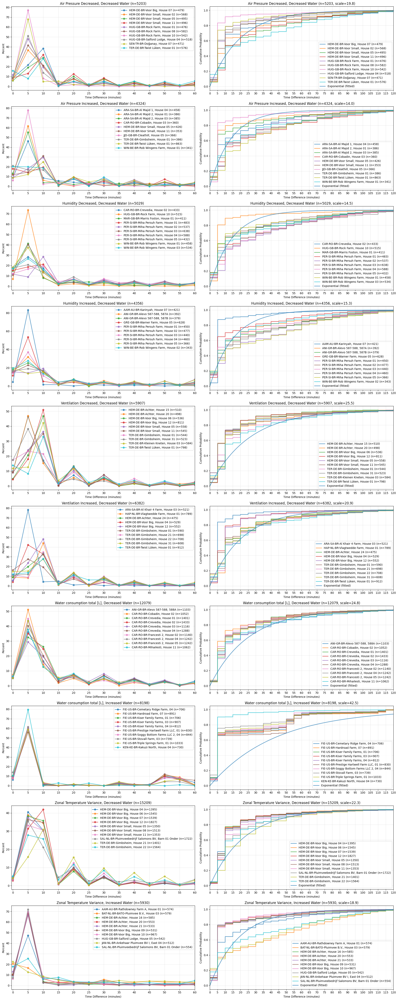

In [ ]:
n_plots = len(result.groupby(['Correlation', 'Category']))
fig, axs = plt.subplots(n_plots, 2, figsize=(20, 5*n_plots))
axs = axs.flatten()
axind = 0

for key,g in result.groupby(['Correlation', 'Category']):
        ax1 = axs[axind]
        ax2 = axs[axind+1]


        # Get real data
        correlation, category = key

        # Get theoretical exponential CDF
        scale = means.get((correlation, category), np.nan)
        time_range = np.linspace(0, upper_limit, 1000)
        theoretical_cdf = stats.expon.cdf(time_range, loc=0, scale=scale)

        for (farmname, shedname), data_subset in g.groupby(['FarmName','ShedName']):
            label = f"{farmname}, {shedname} (n={len(data_subset)})"
            
            # Calculate counts for each bin and convert to percentages
            bin_counts = data_subset['time_diff_binned'].value_counts(normalize=True).sort_index() * 100
            # Multiply by bin length (5 minutes) to get actual time values
            x_values = np.arange(len(bin_counts)) * binwidth_minutes
            ax1.plot(x_values, bin_counts.values, label=label, alpha=0.7, marker='o', linewidth=2)
            # Limit x-axis view
            ax1.set_xlim(-0.5, 60)
            ax1.xaxis.set_major_locator(MultipleLocator(5))

            ax1.set_title(f'{correlation}, {category} (n={len(g)})')
            ax1.set_xlabel('Time Difference (minutes)')
            ax1.set_ylabel('Percent')
            ax1.legend()
            ax1.grid(True, alpha=0.3)

            real_times = np.sort(data_subset['time_diff_minutes'].values)
            real_cdf = np.arange(1, len(real_times) + 1) / len(real_times)
            ax2.step(real_times, real_cdf, where='post', label=label, alpha=0.7, linewidth=2)

            ax2.set_xlim(0, upper_limit)
            ax2.xaxis.set_major_locator(MultipleLocator(5))
            ax2.set_title(f'{correlation}, {category} (n={len(g)}, scale={scale:.1f})')
            ax2.set_xlabel('Time Difference (minutes)')
            ax2.set_ylabel('Cumulative Probability')
            ax2.grid(True, alpha=0.3)

        # Plot CDF
        ax2.plot(time_range, theoretical_cdf, label='Exponential (fitted)', alpha=0.7, linewidth=2)
        ax2.legend()
        axind += 2

plt.tight_layout()
plt.show()

In [45]:
from lifelines.statistics import logrank_test
import itertools


def significance(groups: dict) -> pd.DataFrame:
    results = []

    for (g1, t1), (g2, t2) in itertools.combinations(groups.items(), 2):
        lr = logrank_test(
            t1, t2,
            event_observed_A=[1]*len(t1),
            event_observed_B=[1]*len(t2),
            weightings="wilcoxon"  # early emphasis
        )
        results.append({
            "group_1": g1,
            "group_2": g2,
            "p_value": lr.p_value,
            "test_statistic": lr.test_statistic
        })

    return pd.DataFrame(results)

In [46]:
from scipy.stats import ks_2samp

def pairwise_permuted_ks(groups, n_perm=5000, alternative="two-sided", random_state=None):
    """
    Pairwise permutation-based KS tests for multiple groups.

    Parameters
    ----------
    groups : dict[str, array-like]
        Mapping from group name to 1D array of Δt values.
    n_perm : int
        Number of permutations.
    alternative : {"two-sided", "less", "greater"}
        Passed to scipy.stats.ks_2samp.
    random_state : int or None
        Reproducibility seed.

    Returns
    -------
    pandas.DataFrame
        Columns: group_1, group_2, ks_statistic, p_value
    """
    rng = np.random.default_rng(random_state)
    results = []

    for (g1, dt1), (g2, dt2) in itertools.combinations(groups.items(), 2):
        dt1 = np.asarray(dt1)
        dt2 = np.asarray(dt2)

        # observed KS statistic
        ks_obs = ks_2samp(dt1, dt2, alternative=alternative).statistic # type: ignore

        pooled = np.concatenate([dt1, dt2])
        n1 = len(dt1)

        perm_stats = np.empty(n_perm)
        for i in range(n_perm):
            rng.shuffle(pooled)
            perm_stats[i] = ks_2samp(   # type: ignore
                pooled[:n1],
                pooled[n1:],
                alternative=alternative
            ).statistic

        p_value = np.mean(perm_stats >= ks_obs)

        results.append({
            "group_1": g1,
            "group_2": g2,
            "ks_statistic": ks_obs,
            "p_value": p_value
        })

    return pd.DataFrame(results)


In [47]:
CALCULATE_STATISTICS = False

In [48]:
if CALCULATE_STATISTICS:
        ret = pd.DataFrame()
        for key,g in result.groupby(['Correlation', 'Category']):

                # Get real data
                correlation, category = key
                groups = {}
                for sub_key, data_subset in g.groupby(['ShedId']):
                        shedid = sub_key[0]
                        groups[shedid] = data_subset['time_diff_minutes'].values

                results = pairwise_permuted_ks(groups)

                for i, res in results.iterrows():
                        farm1 = df[df['ShedId'] == res['group_1']]['FarmName'].iloc[0]
                        farm2 = df[df['ShedId'] == res['group_2']]['FarmName'].iloc[0]
                        shed1 = df[df['ShedId'] == res['group_1']]['ShedName'].iloc[0]
                        shed2 = df[df['ShedId'] == res['group_2']]['ShedName'].iloc[0]
                        label = f"{farm1}, {shed1} vs {farm2}, {shed2}"
                        t_ret = pd.DataFrame({
                                'Correlation': [correlation], 'Category': [category],
                                'Farm1': [farm1], 'Shed1': [shed1],
                                'Farm2': [farm2], 'Shed2': [shed2],
                                'p_value': [res['p_value']],
                        })
                        ret = pd.concat([ret, t_ret], ignore_index=True)


In [49]:
if CALCULATE_STATISTICS:
    ret.style.format()  # type: ignore
    ret.style.format(precision=2)  # Control decimals
    ret.style.map(lambda x: 'background-color: yellow' if x > 0.05 else '', subset=['p_value'])